# 03 · Three GNNs, one controlled experiment
Train LightGCN, SIGN and Residual SIGN on the same graph, seeds, negatives, optimizer, learning rate, batch size and epoch budget. Only model capacity and architecture differ.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/data_pipeline.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display, Image
import pandas as pd
from scripts.data_pipeline import OUT, REPORTS


| Model | Graph hops | Hidden width | Output dimensions | Nonlinear trunk layers |
|---|---:|---:|---:|---:|
| LightGCN | 2 | 32 | 32 | 0 |
| SIGN | 2 | 128 | 64 | 2 |
| Residual SIGN | 4 | 256 | 128 | 4 |

**LightGCN variant:** initial embeddings are `XW`, not free node-ID parameters. Averaging `A^h X` before applying `W` is exactly equivalent to linear propagation of `XW`. This intentional attribute-based extension makes metadata available to catalog-only tracks. SIGN uses hop-specific nonlinear projections; the larger model adds depth, width and residual layers.

In [2]:
from scripts.train_models import run
# One common configuration for all three models.
CONFIG = dict(epochs=10, batch_size=2048, lr=0.001, weight_decay=0.0001, max_eval_playlists=1024, device="cpu")
manifest = run(**CONFIG, resume=True)

Keeping completed lightgcn


Keeping completed sign


residual_sign {"epoch": 1, "bpr_loss": 0.23784590240945477, "validation_ndcg_at_10": 0.6376253936285934, "elapsed_seconds": 214.14365180000004}


residual_sign {"epoch": 2, "bpr_loss": 0.16178585190771952, "validation_ndcg_at_10": 0.6261453706541793, "elapsed_seconds": 332.1411131}


residual_sign {"epoch": 3, "bpr_loss": 0.14663785300002669, "validation_ndcg_at_10": 0.6242024878529415, "elapsed_seconds": 436.223165}


...

residual_sign {"epoch": 7, "bpr_loss": 0.12984358992018413, "validation_ndcg_at_10": 0.6187705165411962, "elapsed_seconds": 860.261659}


residual_sign {"epoch": 8, "bpr_loss": 0.12788645502476714, "validation_ndcg_at_10": 0.6233305743457181, "elapsed_seconds": 960.7937744000001}


residual_sign {"epoch": 9, "bpr_loss": 0.12578870797271827, "validation_ndcg_at_10": 0.6237161382341494, "elapsed_seconds": 1059.9560738}


residual_sign {"epoch": 10, "bpr_loss": 0.12400495315071962, "validation_ndcg_at_10": 0.6258962609618148, "elapsed_seconds": 1160.693486}


Saved residual_sign_playlist_recommender.pt


Select checkpoints and the metadata mixture using validation only. Calibrate relative fit scores using validation only. Evaluate each frozen model once on held-out test playlists. Metrics use all held-out positives plus up to 100 sampled negatives per playlist, on a fixed sample of up to 1,024 playlists; they are not full-catalog ranking metrics. Random and training-popularity baselines use the same candidate protocol.

,model,recall_at_10,ndcg_at_10,hit_rate_at_10,mrr_at_10,evaluated_playlists,recommended_unique_tracks,catalog_coverage_at_10,best_epoch,parameters,training_seconds,metadata_weight
0,random,0.093048,0.085981,0.423828,0.153319,1024,10117,0.007727,NaN,NaN,NaN,NaN
1,popularity,0.390450,0.396061,0.749023,0.502336,1024,8920,0.006813,NaN,NaN,NaN,NaN
2,lightgcn,0.570838,0.622868,0.885742,0.739720,1024,9519,0.007270,1.0,2048.0,266.555503,0.6
3,sign,0.583670,0.642270,0.896484,0.767498,1024,9766,0.007459,1.0,66176.0,439.821020,0.6
4,residual_sign,0.606858,0.665457,0.908203,0.787456,1024,9835,0.007511,1.0,379136.0,1179.177830,0.6


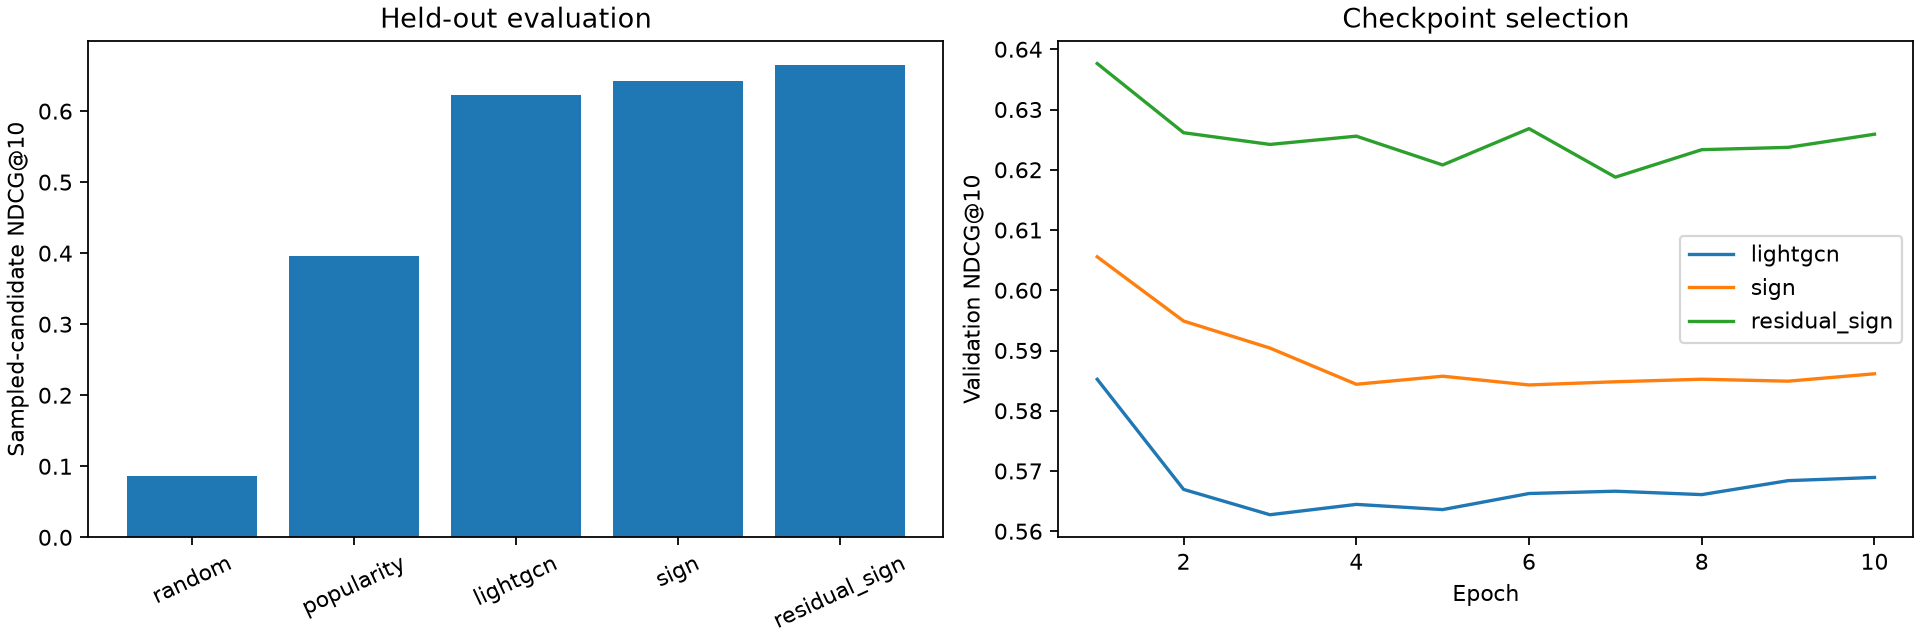

In [3]:
from scripts.project_analysis import training_figures
display(training_figures())
display(Image(filename=str(REPORTS / "model_comparison.png")))

The three `.pt` bundles and their measured scores are listed in `models/manifest.json`. Search uses the shared union catalog; switching models preserves the user playlist. `scripts/start_web_demo.ps1` starts the local API and web interface.